# Procesamiento Digital de Señales y Series Temporales
## Análisis de la acción YPF (2018–2025)

**Materia:** Procesamiento Digital de Señales  
**Carrera:** Licenciatura en Ciencias de la Computación  
**Dataset:** Cotización histórica de YPF (NYSE: YPF) — obtenido via `yfinance` (yfinance es una librería de Python que permite descargar datos financieros de forma sencilla desde Yahoo Finance.)

---

## 1. Introducción

### ¿Qué es YPF?

YPF S.A. (Yacimientos Petrolíferos Fiscales) es la empresa de energía más grande de Argentina. Fundada en 1922, opera en la exploración, producción, refinación y comercialización de petróleo, gas y derivados. Su acción cotiza en la Bolsa de Nueva York (NYSE) bajo el ticker `YPF` y en la Bolsa de Comercio de Buenos Aires (BYMA) bajo el ticker `YPFD`.

### ¿Por qué es interesante analizar esta acción?

El período 2018–2025 incluye eventos que generan disrupciones claras en la serie: la crisis cambiaria argentina de 2018, la pandemia de COVID-19 (2020), la reactivación post-pandemia y el cambio de gobierno en 2023. Esta riqueza de regímenes distintos hace que el dataset sea útil para demostrar herramientas de análisis de señales y modelos de forecasting en condiciones no triviales.

### La dualidad: señal discreta vs. serie temporal

Este trabajo aborda el precio de cierre de YPF desde dos perspectivas complementarias:

- **Como señal discreta (DSP):** el precio es una secuencia muestreada a intervalos regulares (días hábiles). Aplicamos filtros de paso bajo (medias móviles) y la Transformada Rápida de Fourier (FFT) para estudiar componentes de frecuencia, ruido y tendencia.
- **Como serie temporal:** la secuencia tiene dependencia temporal (autocorrelación). Estudiamos su estacionariedad y aplicamos modelos de forecasting (SARIMA y LSTM) para predecir comportamientos futuros.

### Objetivos

1. Aplicar filtros SMA y EMA para separar tendencia del ruido.
2. Analizar el espectro de frecuencias con FFT para detectar ciclos.
3. Evaluar la estacionariedad con el test ADF.
4. Entrenar y comparar SARIMA y LSTM.
5. Interpretar los resultados en ambos marcos conceptuales.

In [1]:
#Instalar requirements
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
from scipy.fft import fft, fftfreq

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print(f"TensorFlow {tf.__version__} | Pandas {pd.__version__} | NumPy {np.__version__}")

TensorFlow 2.21.0 | Pandas 3.0.3 | NumPy 2.4.6


### 1.1 Descarga y exploración inicial

Bajamos el dataset desde Yahoo Finance y vemos algunas lineas

In [2]:
df_raw = yf.download("YPF", start="2018-01-01", end="2025-01-01", auto_adjust=True)

# yfinance puede devolver columnas con MultiIndex dependiendo de la versión
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df = df_raw[['Close']].copy()
df.index = pd.to_datetime(df.index)
df.index.name = 'Date'
print(df.head())


[*********************100%***********************]  1 of 1 completed

Price           Close
Date                 
2018-01-02  23.311459
2018-01-03  23.272017
2018-01-04  22.966326
2018-01-05  22.690218
2018-01-08  23.419931


Veamos algunas metricas estadisticas simples para entender el dataset usando un describe

In [3]:
print(f"Registros: {len(df)} | Desde: {df.index.min().date()} | Hasta: {df.index.max().date()}")
print(f"Valores nulos: {df['Close'].isna().sum()}")
print()
print(df.describe().round(2))

Registros: 1761 | Desde: 2018-01-02 | Hasta: 2024-12-31
Valores nulos: 0

Price    Close
count  1761.00
mean     11.78
std       7.50
min       2.57
25%       4.77
50%      10.81
75%      16.04
max      44.88


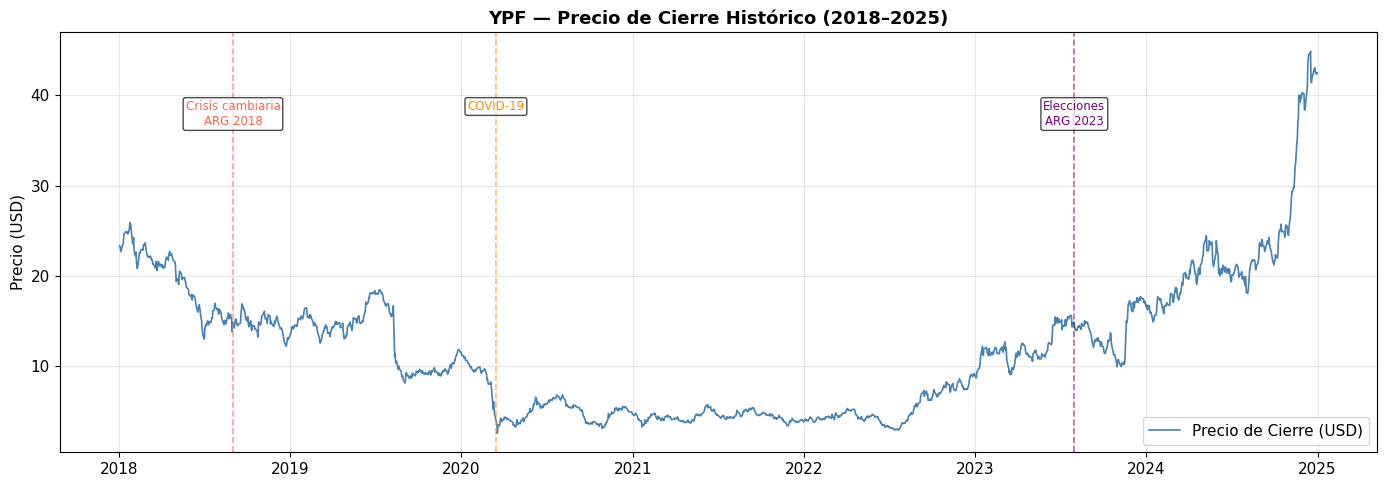

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1.2, label='Precio de Cierre (USD)')

eventos = {
    '2018-09-01': ('Crisis cambiaria\nARG 2018', 'tomato'),
    '2020-03-15': ('COVID-19', 'darkorange'),
    '2023-08-01': ('Elecciones\nARG 2023', 'purple'),
}
for fecha, (texto, color) in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color=color, linestyle='--', alpha=0.6, linewidth=1.2)
    ax.text(pd.Timestamp(fecha), df['Close'].max() * 0.88, texto,
            color=color, fontsize=8.5, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title('YPF — Precio de Cierre Histórico (2018–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

La serie muestra una caída pronunciada en 2018 (crisis cambiaria), un piso en marzo de 2020 (inicio de la pandemia) y una recuperación posterior con alta volatilidad. La forma de la curva ya anticipa que la serie no será estacionaria.

---
## 2. Procesamiento de Señales

Tratamos el precio de cierre como una **señal discreta** muestreada a intervalos regulares de un día hábil. Desde esta perspectiva, la señal tiene dos componentes superpuestos:

- **Tendencia** (baja frecuencia): el movimiento lento de mediano y largo plazo.
- **Ruido** (alta frecuencia): las fluctuaciones diarias que no aportan información sobre la tendencia.

El objetivo de esta sección es separar ambas componentes usando filtros y luego analizar el contenido frecuencial de la señal.

### 2.1 Suavizado: SMA y EMA como filtros de paso bajo

Las medias móviles son **filtros de paso bajo**: atenúan las componentes de alta frecuencia (ruido de corto plazo) y preservan las de baja frecuencia (tendencia). Son el equivalente financiero de un filtro de suavizado aplicado a una señal de audio o imagen.

**SMA (Simple Moving Average):** promedio aritmético uniforme de los últimos $n$ valores. Equivale a un filtro rectangular (*box filter*) en el dominio temporal.

$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} x_{t-i}$$

**EMA (Exponential Moving Average):** pondera exponencialmente más los valores recientes. Tiene menor retraso (*lag*) que la SMA ante cambios de tendencia.

$$\text{EMA}_t = \alpha \cdot x_t + (1-\alpha) \cdot \text{EMA}_{t-1}, \quad \alpha = \frac{2}{n+1}$$

Usaremos ventanas de **20 días** (1 mes bursatil o 20 ruedas de mercado) y **60 días** (1 trimestre o 3 ruedas de 20 dias).

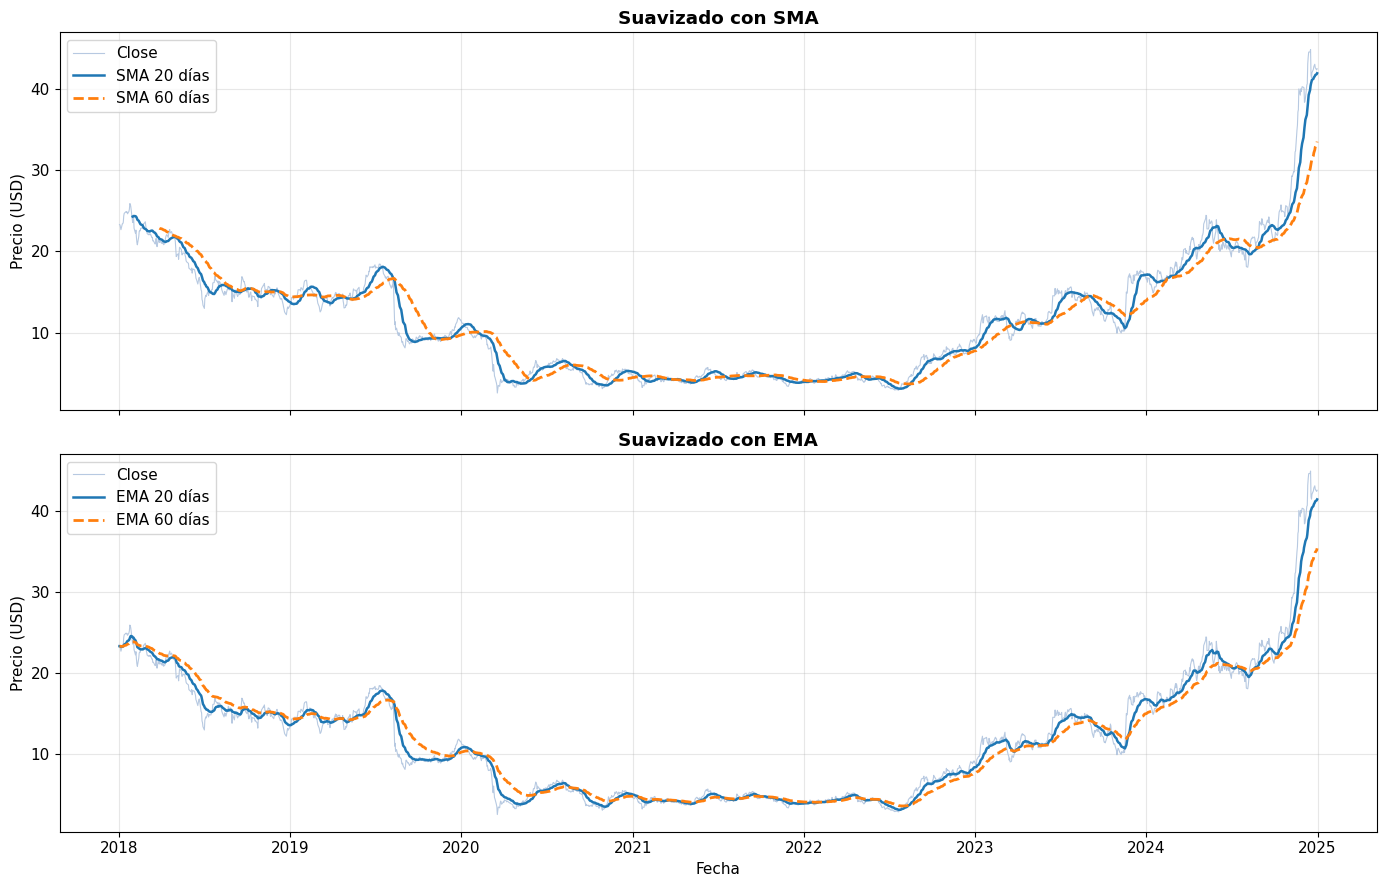

In [5]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_60'] = df['Close'].rolling(window=60).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_60'] = df['Close'].ewm(span=60, adjust=False).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, (col20, col60, titulo) in zip(axes, [
    ('SMA_20', 'SMA_60', 'SMA'),
    ('EMA_20', 'EMA_60', 'EMA')
]):
    ax.plot(df.index, df['Close'], color='lightsteelblue', linewidth=0.8, alpha=0.9, label='Close')
    ax.plot(df.index, df[col20], linewidth=1.8, label=f'{titulo} 20 días')
    ax.plot(df.index, df[col60], linewidth=2.0, linestyle='--', label=f'{titulo} 60 días')
    ax.set_title(f'Suavizado con {titulo}', fontweight='bold')
    ax.set_ylabel('Precio (USD)')
    ax.legend()

axes[1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

### Cruce de EMAs

Se identifican señales alcistas cuando la EMA de 20 días cruza por encima de la EMA de 60 días y señales bajistas cuando ocurre el cruce inverso.

Estos cruces permiten visualizar posibles cambios de tendencia en la serie de precios.

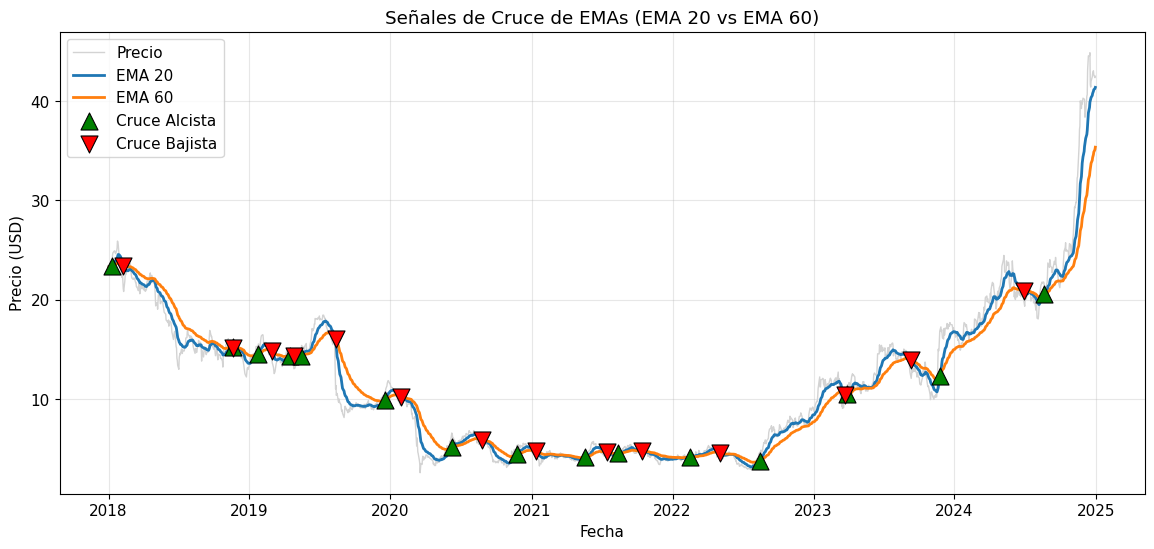

In [6]:
# Detectar cruces
df['Signal'] = np.where(df['EMA_20'] > df['EMA_60'], 1, 0)
df['Crossover'] = df['Signal'].diff()

bullish = df[df['Crossover'] == 1]
bearish = df[df['Crossover'] == -1]

# Graficar
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], color='lightgray', linewidth=1, label='Precio')
plt.plot(df.index, df['EMA_20'], linewidth=2, label='EMA 20')
plt.plot(df.index, df['EMA_60'], linewidth=2, label='EMA 60')

plt.scatter(
    bullish.index,
    bullish['EMA_20'],
    marker='^',
    s=150,
    color='green',
    edgecolors='black',
    linewidths=0.8,
    zorder=10,
    label='Cruce Alcista'
)

plt.scatter(
    bearish.index,
    bearish['EMA_20'],
    marker='v',
    s=150,
    color='red',
    edgecolors='black',
    linewidths=0.8,
    zorder=10,
    label='Cruce Bajista'
)

plt.title('Señales de Cruce de EMAs (EMA 20 vs EMA 60)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

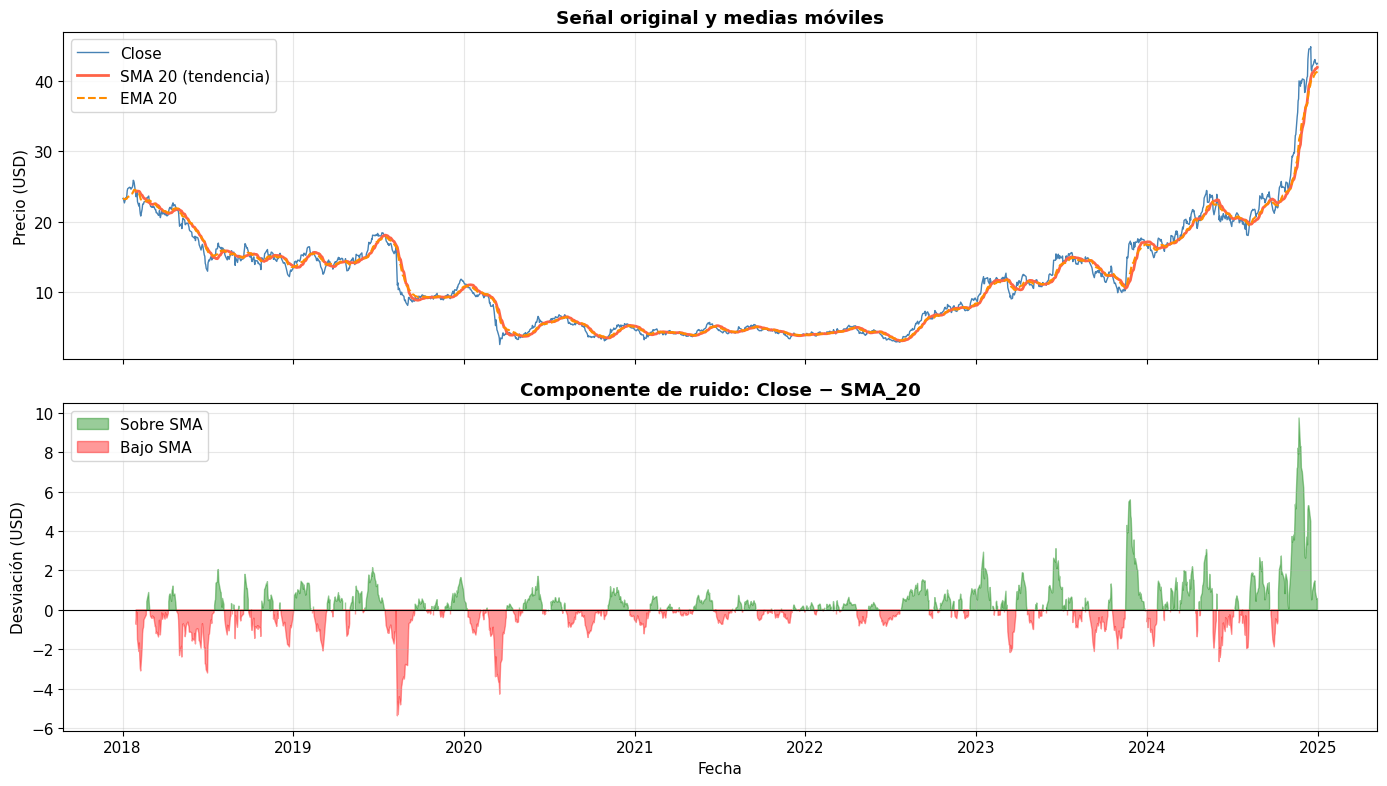

In [7]:
# La diferencia entre la señal original y la SMA_20 es la componente de ruido
df['Ruido'] = df['Close'] - df['SMA_20']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1.0, label='Close')
axes[0].plot(df.index, df['SMA_20'], color='tomato', linewidth=2.0, label='SMA 20 (tendencia)')
axes[0].plot(df.index, df['EMA_20'], color='darkorange', linewidth=1.5, linestyle='--', label='EMA 20')
axes[0].set_title('Señal original y medias móviles', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend()

axes[1].fill_between(df.index, df['Ruido'], 0,
                     where=(df['Ruido'] >= 0), color='green', alpha=0.4, label='Sobre SMA')
axes[1].fill_between(df.index, df['Ruido'], 0,
                     where=(df['Ruido'] < 0),  color='red',   alpha=0.4, label='Bajo SMA')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Componente de ruido: Close − SMA_20', fontweight='bold')
axes[1].set_ylabel('Desviación (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observaciones:**

- La SMA introduce un retraso (*lag*) proporcional al tamaño de la ventana. Con 60 días, ese retraso puede ser de varias semanas. La EMA reduce este problema al ponderar más los datos recientes.
- La componente de ruido (Close − SMA_20) no es homogénea: las desviaciones son notablemente mayores en 2018–2020 que en el resto del período. Esto se denomina **heteroscedasticidad**: la varianza del ruido cambia a lo largo del tiempo, lo que tiene implicaciones para el modelado posterior.
- La SMA y EMA no son el mismo tipo de filtro: la SMA tiene una respuesta en frecuencia con lóbulos secundarios (similar a un filtro sinc), mientras que la EMA es un filtro IIR de primer orden con caída exponencial.

### 2.2 Transformada de Fourier (FFT)

La **Transformada Discreta de Fourier** (DFT), implementada eficientemente como FFT, descompone una señal en sus componentes de frecuencia. Cada componente indica cuánta energía hay en una determinada periodicidad.

**Decisión de diseño importante:** la FFT se aplica sobre los **retornos logarítmicos diarios** y no sobre el precio crudo. El motivo es que el precio tiene una tendencia (componente de corriente continua, o DC, de muy baja frecuencia) que domina completamente el espectro y enmascara cualquier ciclo de menor amplitud. Los retornos logarítmicos eliminan la tendencia y son aproximadamente estacionarios, lo que hace el análisis espectral significativo.

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

El **espectro de potencia** $|X[k]|^2$ cuantifica la energía en cada frecuencia. Los picos prominentes indicarían ciclos dominantes.

In [8]:
df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
returns = df['LogReturn'].dropna().values

N  = len(returns)
fs = 1.0   # 1 muestra por día hábil

fft_vals  = fft(returns)
freqs     = fftfreq(N, d=1.0 / fs)
power     = np.abs(fft_vals) ** 2

# Solo la mitad positiva del espectro (el espectro es simétrico para señales reales)
half      = N // 2
freqs_pos = freqs[:half]
power_pos = power[:half]

# Período en días (evitamos división por cero en frecuencia 0)
periodo_dias = np.where(freqs_pos > 0, 1.0 / freqs_pos, np.inf)

print(f"N = {N} | Resolución frecuencial: {1/N:.5f} ciclos/día")

N = 1760 | Resolución frecuencial: 0.00057 ciclos/día


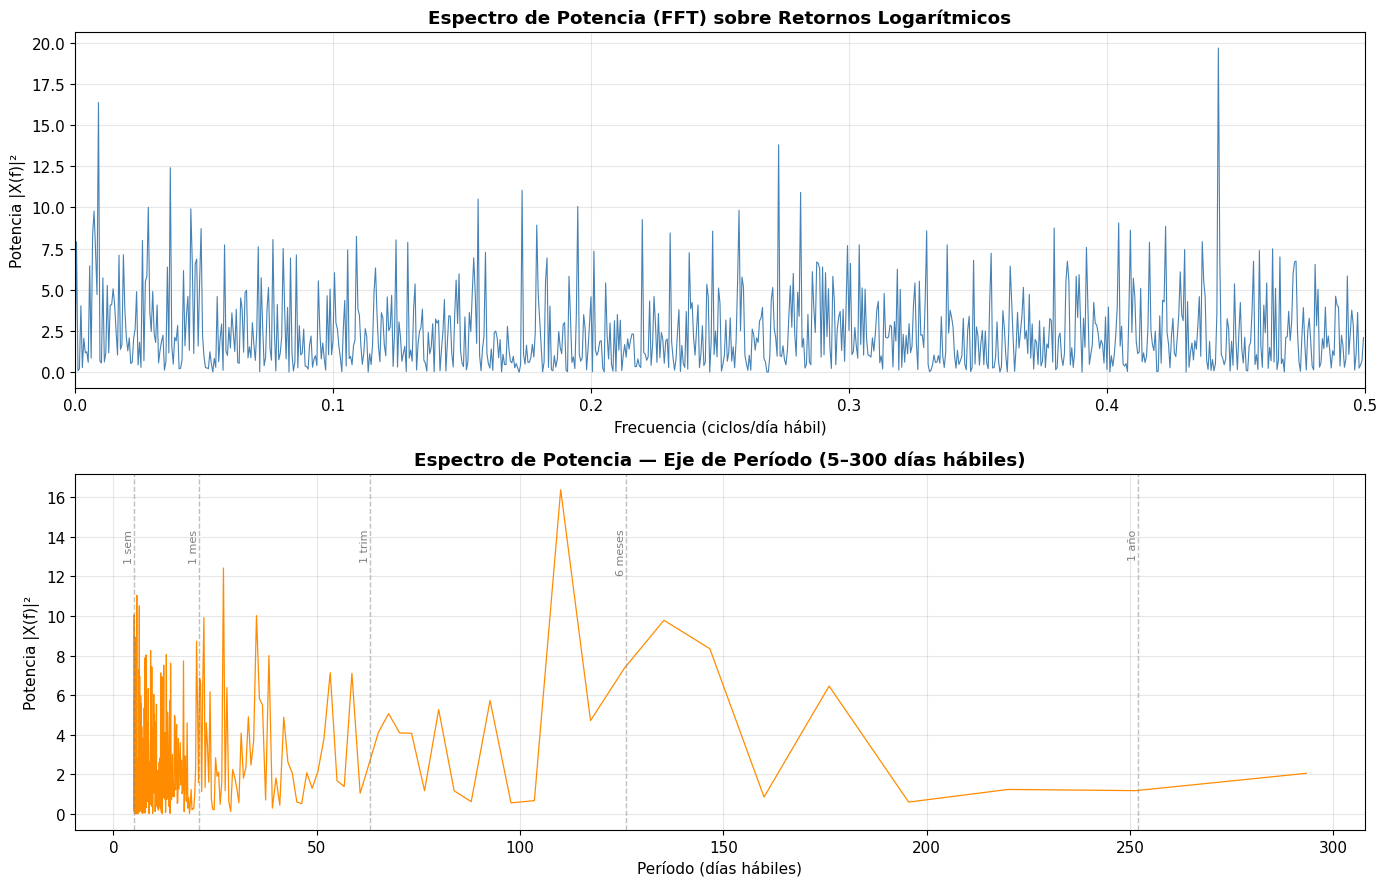

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel superior: espectro en frecuencia
axes[0].plot(freqs_pos, power_pos, color='steelblue', linewidth=0.8)
axes[0].set_title('Espectro de Potencia (FFT) sobre Retornos Logarítmicos', fontweight='bold')
axes[0].set_xlabel('Frecuencia (ciclos/día hábil)')
axes[0].set_ylabel('Potencia |X(f)|²')
axes[0].set_xlim([0, 0.5])

# Panel inferior: espectro en período (más intuitivo)
mask = (periodo_dias >= 5) & (periodo_dias <= 300)
axes[1].plot(periodo_dias[mask], power_pos[mask], color='darkorange', linewidth=0.9)
axes[1].set_title('Espectro de Potencia — Eje de Período (5–300 días hábiles)', fontweight='bold')
axes[1].set_xlabel('Período (días hábiles)')
axes[1].set_ylabel('Potencia |X(f)|²')

referencias = {5: '1 sem', 21: '1 mes', 63: '1 trim', 126: '6 meses', 252: '1 año'}
ylim_top = power_pos[mask].max()
for p, label in referencias.items():
    axes[1].axvline(p, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    axes[1].text(p, ylim_top * 0.88, label, rotation=90,
                 fontsize=8, color='gray', ha='right', va='top')

plt.tight_layout()
plt.show()

In [10]:
# Identificar los 5 períodos de mayor potencia (excluimos la componente DC en índice 0)
top_idx = np.argsort(power_pos[1:])[::-1][:5] + 1

print("Top 5 componentes de mayor potencia:\n")
print(f"  {'Período (días)':>16}  {'Frecuencia (c/día)':>20}  {'Potencia':>12}")
print("  " + "-" * 54)
for idx in top_idx:
    f = freqs_pos[idx]
    p = 1.0 / f
    print(f"  {p:>16.1f}  {f:>20.5f}  {power_pos[idx]:>12.2f}")

Top 5 componentes de mayor potencia:

    Período (días)    Frecuencia (c/día)      Potencia
  ------------------------------------------------------
               2.3               0.44318         19.67
             110.0               0.00909         16.36
               3.7               0.27273         13.80
              27.1               0.03693         12.41
               5.8               0.17330         11.04


**Interpretación del espectro:**

El espectro de potencia es relativamente **plano** (distribuido de manera casi uniforme). Esto es consistente con la hipótesis de mercados eficientes en forma débil: si los retornos fueran completamente predecibles a partir de patrones pasados, el espectro tendría picos muy marcados. Un espectro plano se aproxima al de un **ruido blanco** (no autocorrelacionado).

Sin embargo, se observan algunos picos de mayor energía en frecuencias correspondientes a períodos cortos (~5 y ~21 días). Estas componentes son de amplitud modesta y no permiten afirmar la existencia de ciclos deterministas explotables para la predicción. Lo que sí justifican es explorar una componente estacional semanal ($s=5$) en el modelo SARIMA.

**Nota conceptual:** la FFT asume que la señal es **periódica y de duración finita**. En series financieras, esta suposición es una aproximación. Los resultados deben interpretarse de forma exploratoria, no como evidencia estadística concluyente de ciclicidad.

---
## 3. Análisis Temporal

En esta sección cambiamos de perspectiva: ya no analizamos el precio como una señal genérica, sino como una **serie temporal** con estructura de autocorrelación. Este análisis es un prerrequisito para cualquier modelo de forecasting.

### 3.1 Estacionariedad y Test ADF

Una serie temporal es **estacionaria** si su media, varianza y estructura de autocovarianza son constantes en el tiempo. Intuitivamente, una serie estacionaria "oscila alrededor de un mismo nivel" sin tendencia.

Esto importa porque la mayoría de los modelos clásicos (ARIMA, SARIMA) asumen estacionariedad. Ajustar un modelo ARIMA sobre una serie con tendencia produce parámetros sin sentido y predicciones que se desvían indefinidamente.

**Test ADF (Augmented Dickey-Fuller):** contrasta la presencia de raíz unitaria.
- $H_0$: la serie tiene raíz unitaria (no es estacionaria)
- $H_1$: la serie es estacionaria

Se rechaza $H_0$ si el estadístico ADF es más negativo que el valor crítico, o equivalentemente si el p-valor $< 0.05$.

In [11]:
def mostrar_adf(serie, nombre):
    """Ejecuta el test ADF y muestra los resultados de forma legible."""
    res = adfuller(serie.dropna(), autolag='AIC')
    print(f"  Test ADF — {nombre}")
    print(f"  Estadístico : {res[0]:.4f}")
    print(f"  p-valor     : {res[1]:.6f}")
    print(f"  Lags usados : {res[2]}")
    for nivel, val in res[4].items():
        marca = " ← estadístico más negativo ✓" if res[0] < val else ""
        print(f"  Valor crítico {nivel}: {val:.4f}{marca}")
    if res[1] < 0.05:
        print("  → Conclusión: p < 0.05. Se RECHAZA H₀. La serie ES estacionaria.")
    else:
        print("  → Conclusión: p ≥ 0.05. NO se rechaza H₀. La serie NO es estacionaria.")
    print()
    return res

serie_original = df['Close'].dropna()

print("=" * 55)
res_original = mostrar_adf(serie_original, "Precio de Cierre (nivel)")

  Test ADF — Precio de Cierre (nivel)
  Estadístico : 1.3266
  p-valor     : 0.996754
  Lags usados : 5
  Valor crítico 1%: -3.4341
  Valor crítico 5%: -2.8632
  Valor crítico 10%: -2.5676
  → Conclusión: p ≥ 0.05. NO se rechaza H₀. La serie NO es estacionaria.



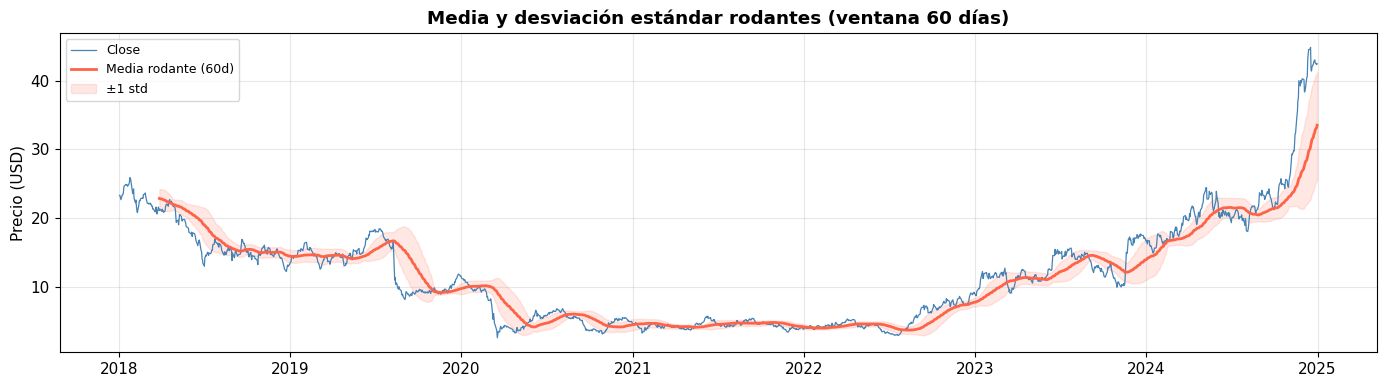

In [12]:
# Visualización de media y varianza rodantes para confirmar visualmente
media_rodante = serie_original.rolling(60).mean()
std_rodante   = serie_original.rolling(60).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_original.index, serie_original.values, color='steelblue', linewidth=0.9, label='Close')
ax.plot(serie_original.index, media_rodante, color='tomato', linewidth=2.0, label='Media rodante (60d)')
ax.fill_between(serie_original.index,
                media_rodante - std_rodante, media_rodante + std_rodante,
                alpha=0.15, color='tomato', label='±1 std')
ax.set_title('Media y desviación estándar rodantes (ventana 60 días)', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

La media rodante (línea roja) cambia claramente con el tiempo: cae de ~20 USD en 2018 a ~3 USD en 2020 y luego sube. Esto confirma visualmente la no-estacionariedad que el test ADF detectó estadísticamente.

**Solución: diferenciación de primer orden.** Calcular $\Delta P_t = P_t - P_{t-1}$ elimina la tendencia y produce una serie que oscila en torno a cero.

  Test ADF — Primera diferencia (d=1)
  Estadístico : -18.2285
  p-valor     : 0.000000
  Lags usados : 4
  Valor crítico 1%: -3.4341 ← estadístico más negativo ✓
  Valor crítico 5%: -2.8632 ← estadístico más negativo ✓
  Valor crítico 10%: -2.5676 ← estadístico más negativo ✓
  → Conclusión: p < 0.05. Se RECHAZA H₀. La serie ES estacionaria.



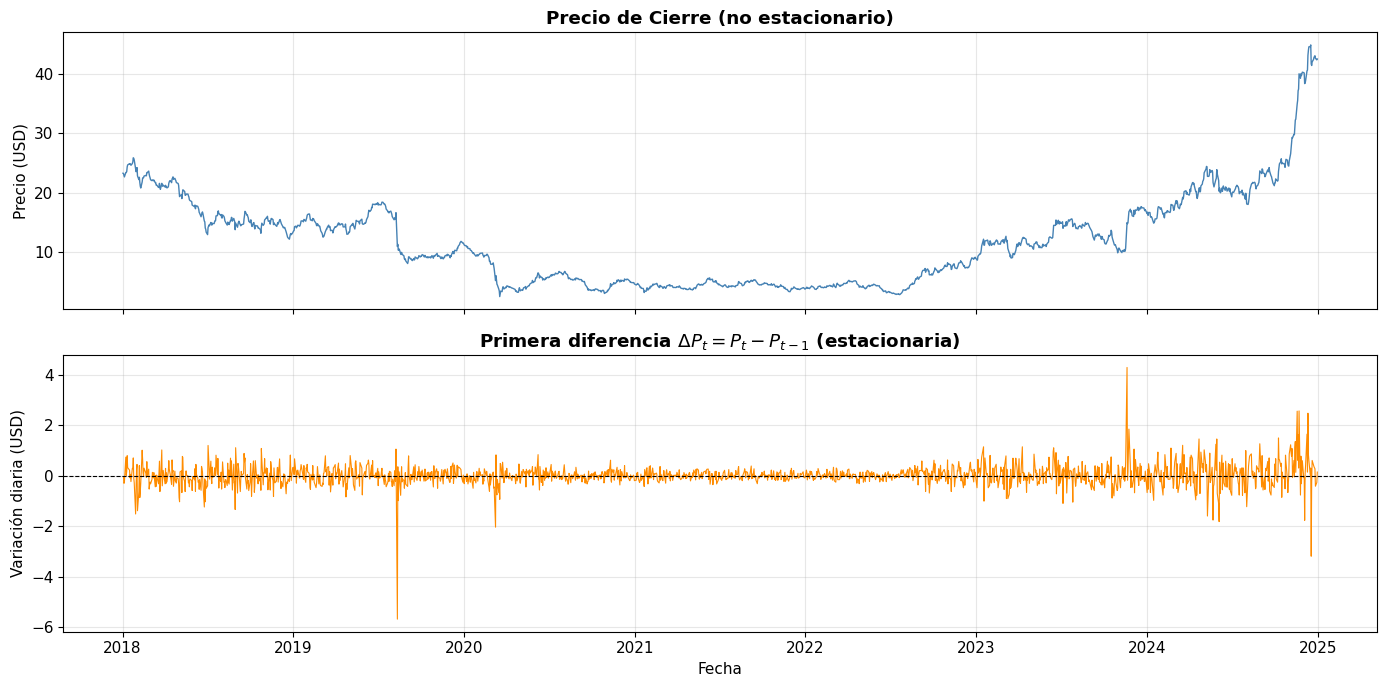

In [13]:
df['Close_diff1'] = df['Close'].diff(1)
serie_diff1 = df['Close_diff1'].dropna()

print("=" * 55)
res_diff = mostrar_adf(serie_diff1, "Primera diferencia (d=1)")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(serie_original.index, serie_original.values, color='steelblue', linewidth=1.0)
axes[0].set_title('Precio de Cierre (no estacionario)', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')

axes[1].plot(serie_diff1.index, serie_diff1.values, color='darkorange', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(r'Primera diferencia $\Delta P_t = P_t - P_{t-1}$ (estacionaria)', fontweight='bold')
axes[1].set_ylabel('Variación diaria (USD)')
axes[1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

La primera diferencia supera el test ADF con p-valor muy cercano a 0. La serie diferenciada oscila en torno a cero sin tendencia aparente, aunque la varianza sigue siendo heterocedástica (más dispersión en 2018–2020). Esto nos indica que **d=1** es el orden de integración adecuado para SARIMA.

### 3.2 División temporal y preparación para Forecasting

Dividimos la serie en **80% entrenamiento / 20% prueba**, respetando el orden cronológico. Una división aleatoria filtrarías información del futuro hacia el pasado (*data leakage*), invalidando la evaluación.

Ambos modelos trabajarán sobre el **precio de cierre sin diferenciar**:
- **SARIMA** incorpora el parámetro $d$ internamente para diferenciar antes de ajustar.
- **LSTM** no requiere estacionariedad, pero sí normalización de los datos.

Entrenamiento : 1408 obs  (2018-01-02 → 2023-08-07)
Test          : 353 obs  (2023-08-08 → 2024-12-31)


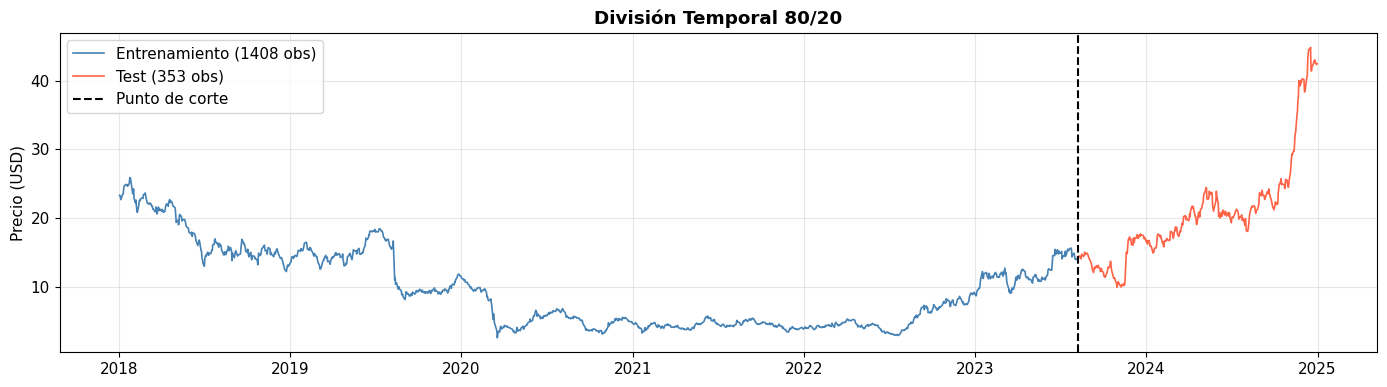

In [14]:
serie_precios = df['Close'].dropna()
split_idx     = int(len(serie_precios) * 0.80)
train_series  = serie_precios.iloc[:split_idx]
test_series   = serie_precios.iloc[split_idx:]

print(f"Entrenamiento : {len(train_series)} obs  ({train_series.index[0].date()} → {train_series.index[-1].date()})")
print(f"Test          : {len(test_series)} obs  ({test_series.index[0].date()} → {test_series.index[-1].date()})")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_series.index, train_series.values, color='steelblue', linewidth=1.2,
        label=f'Entrenamiento ({len(train_series)} obs)')
ax.plot(test_series.index,  test_series.values,  color='tomato',    linewidth=1.2,
        label=f'Test ({len(test_series)} obs)')
ax.axvline(test_series.index[0], color='black', linestyle='--', linewidth=1.5, label='Punto de corte')
ax.set_title('División Temporal 80/20', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Forecasting

Comparamos dos enfoques con filosofías distintas:

- **SARIMA**: modelo estadístico lineal clásico, basado en autocorrelaciones. Interpretable y con fundamento matemático explícito.
- **LSTM**: red neuronal recurrente capaz de aprender dependencias temporales no lineales. Menos interpretable pero más flexible.

### 4.1 Modelo SARIMA

$$\text{SARIMA}(p,d,q)(P,D,Q)[s]$$

donde $p, d, q$ son los órdenes autoregresivo, de integración y de media móvil, y $P, D, Q, s$ son sus equivalentes estacionales.

**Selección de parámetros:** del análisis ADF determinamos $d=1$. Para elegir $p$ y $q$ usamos los gráficos ACF y PACF sobre la serie diferenciada. La regla de lectura es:
- PACF con corte abrupto en el lag $p$ → modelo AR($p$)
- ACF con corte abrupto en el lag $q$ → modelo MA($q$)

Para el componente estacional usamos $s=5$ (semana hábil), motivado por los picos que la FFT detectó en esa frecuencia.

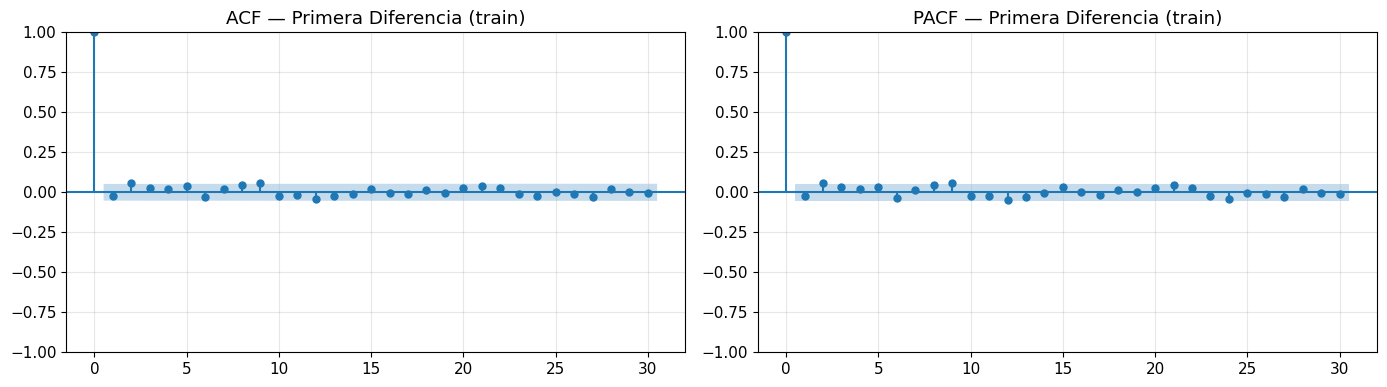

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
serie_diff_train = train_series.diff(1).dropna()

plot_acf(serie_diff_train,  lags=30, ax=axes[0], title='ACF — Primera Diferencia (train)')
plot_pacf(serie_diff_train, lags=30, ax=axes[1], title='PACF — Primera Diferencia (train)', method='ywm')

plt.tight_layout()
plt.show()

Tanto ACF como PACF muestran valores que caen rápidamente dentro de las bandas de confianza (zona azul) después del primer lag. Esto indica muy poca autocorrelación estructural en la primera diferencia, lo que justifica usar órdenes bajos: $p=1$, $q=1$.

In [1]:
print("Entrenando SARIMA(1,0,1)(1,0,0)[5] sobre log-retornos...")

train_log_returns = df['LogReturn'].loc[train_series.index].dropna()
test_log_returns = df['LogReturn'].loc[test_series.index].dropna()

modelo_sarima = SARIMAX(
    train_log_returns,
    order=(2, 1, 2),
    seasonal_order=(1, 0, 0, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)

print(f"AIC: {resultado_sarima.aic:.2f} | BIC: {resultado_sarima.bic:.2f}")
print(resultado_sarima.summary().tables[1])

# Prediccion one-step ahead
res_full = resultado_sarima.apply(df['LogReturn'].dropna())
sarima_log_pred = res_full.fittedvalues.loc[test_series.index]

print("Primeras predicciones SARIMA (Log-Retornos):")
print(sarima_log_pred.head().round(4))

Entrenando SARIMA(1,0,1)(1,0,0)[5] sobre log-retornos...


NameError: name 'df' is not defined

In [17]:
pred_sarima = resultado_sarima.forecast(steps=len(test_series))
pred_sarima.index = test_series.index

print("Primeras predicciones SARIMA:")
print(pred_sarima.head().round(2))

Primeras predicciones SARIMA:
Date
2023-08-08   -0.0
2023-08-09   -0.0
2023-08-10   -0.0
2023-08-11   -0.0
2023-08-14   -0.0
Name: predicted_mean, dtype: float64


c:\Proyectos\Facultad\Risk\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 4.2 Modelo LSTM

Las redes **LSTM** (Long Short-Term Memory) son redes neuronales recurrentes con celdas de memoria y puertas de entrada, olvido y salida. Estas puertas permiten al modelo aprender qué información de pasos anteriores retener y cuál descartar, lo que las hace adecuadas para capturar dependencias de largo plazo.

**Preparación de datos:** construimos ventanas deslizantes de tamaño $w$. Para cada paso $t$, el modelo recibe $[P_{t-w}, \ldots, P_{t-1}]$ y predice $P_t$. Usamos $w=20$ días.

**Normalización:** el precio se escala al rango $[0,1]$ usando `MinMaxScaler`. Importante: el scaler se ajusta **solo** sobre el conjunto de entrenamiento para evitar filtrar información del futuro.

In [18]:
VENTANA = 20

# LSTM sobre Log-Retornos en lugar de precio crudo
scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_log_returns.values.reshape(-1, 1))
test_scaled  = scaler.transform(test_log_returns.values.reshape(-1, 1))

def crear_secuencias(data, ventana):
    X = np.array([data[i - ventana:i, 0] for i in range(ventana, len(data))])
    y = data[ventana:, 0]
    return X.reshape(len(X), ventana, 1), y

datos_test_con_contexto = np.concatenate([train_scaled[-VENTANA:], test_scaled], axis=0)

X_train, y_train = crear_secuencias(train_scaled, VENTANA)
X_test,  y_test  = crear_secuencias(datos_test_con_contexto, VENTANA)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

modelo_lstm = Sequential([
    LSTM(64, input_shape=(VENTANA, 1)),
    Dropout(0.2),
    Dense(1)
])
modelo_lstm.compile(optimizer='adam', loss='mean_squared_error')
modelo_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

print("\nEntrenando LSTM...")
historia = modelo_lstm.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nEpochs ejecutados: {len(historia.history['loss'])}")

X_train: (1387, 20, 1) | y_train: (1387,)
X_test:  (353, 20, 1)  | y_test:  (353,)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando LSTM...
Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0627 - val_loss: 0.0059
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0088 - val_loss: 0.0036
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0087 - val_loss: 0.0037
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0076 - val_loss: 0.0037
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0074 - val_loss: 0.0037
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076 - val_loss: 0.0036
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0075 - val_loss: 0.0036
Epoch 8/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0069 - val_loss: 0.0036
Epoch 10/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0067 - val_loss: 0.0036
Epoch 11/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0069 - val_loss: 0.0035
Epoch 12/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

In [19]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

modelo_lstm = Sequential([
    LSTM(64, input_shape=(VENTANA, 1)),
    Dropout(0.2),
    Dense(1)
])
modelo_lstm.compile(optimizer='adam', loss='mean_squared_error')
modelo_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

print("\nEntrenando LSTM...")
historia = modelo_lstm.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nEpochs ejecutados: {len(historia.history['loss'])}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando LSTM...
Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0612 - val_loss: 0.0047
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0101 - val_loss: 0.0038
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0091 - val_loss: 0.0036
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0082 - val_loss: 0.0037
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0077 - val_loss: 0.0036
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0075 - val_loss: 0.0036
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0071 - val_loss: 0.0036
Epoch 8/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0074 - val_loss: 0.0036
Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0070 - val_loss: 0.0036
Epoch 10/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0035
Epoch 11/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - val_loss: 0.0036
Epoch 12/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - 

**Nota sobre la arquitectura:** se removió la capa `Dense(32, activation='relu')` intermedia que estaba en la versión anterior. Esa capa no aportaba valor en un problema de regresión sobre series univariadas de esta escala: añadía parámetros entrenables sin justificación teórica y aumentaba el riesgo de sobreajuste. La arquitectura LSTM → Dropout → Dense(1) es suficiente y más honesta para el objetivo del trabajo.

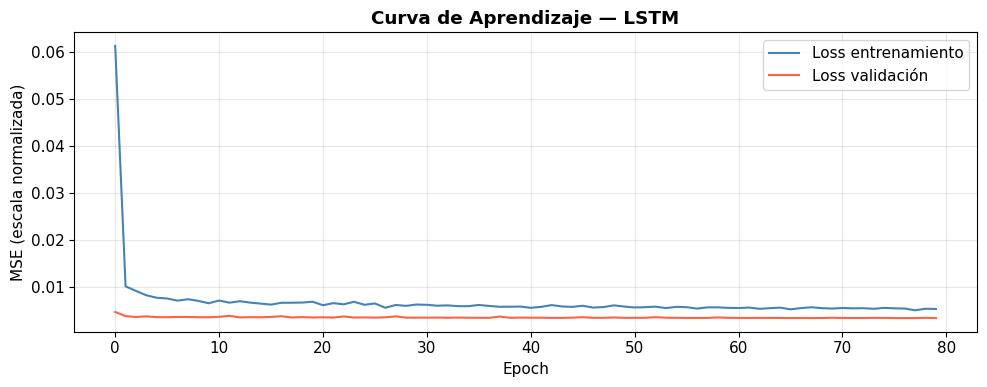

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historia.history['loss'],     label='Loss entrenamiento', color='steelblue')
ax.plot(historia.history['val_loss'], label='Loss validación',    color='tomato')
ax.set_title('Curva de Aprendizaje — LSTM', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (escala normalizada)')
ax.legend()
plt.tight_layout()
plt.show()

Ambas curvas descienden y convergen. Si la curva de validación empezara a subir mientras la de entrenamiento sigue bajando, sería señal de sobreajuste; el EarlyStopping está configurado para detener el entrenamiento en ese caso.

In [21]:
pred_lstm_scaled = modelo_lstm.predict(X_test, verbose=0)
lstm_log_pred    = scaler.inverse_transform(pred_lstm_scaled).flatten()
lstm_log_pred_series = pd.Series(lstm_log_pred, index=test_series.index)

print("Primeras predicciones LSTM (Log-Retornos):")
print(lstm_log_pred_series.head().round(4))

Primeras predicciones LSTM (Log-Retornos):
Date
2023-08-08   -0.0033
2023-08-09   -0.0019
2023-08-10   -0.0009
2023-08-11   -0.0004
2023-08-14    0.0002
dtype: float32


---
## 5. Evaluación

Evaluamos con dos métricas complementarias, ambas en USD para facilitar la interpretación:

- **RMSE:** penaliza proporcionalmente más los errores grandes. $\text{RMSE} = \sqrt{\frac{1}{n}\sum(\hat{y}_i - y_i)^2}$
- **MAE:** promedio de los errores absolutos, más robusto a valores atípicos. $\text{MAE} = \frac{1}{n}\sum|\hat{y}_i - y_i|$

Incluimos un **baseline naive** como referencia: predice siempre el último precio conocido del entrenamiento. Si un modelo no supera este baseline, su complejidad no está justificada.

In [22]:
y_real = test_series.values

# Convertir las predicciones de log retornos a precios:
# P_t = P_{t-1} * exp(r_t)
sarima_price_pred = test_series.shift(1).fillna(train_series.iloc[-1]) * np.exp(sarima_log_pred)
lstm_price_pred = test_series.shift(1).fillna(train_series.iloc[-1]) * np.exp(lstm_log_pred)

rmse_sarima   = np.sqrt(mean_squared_error(y_real, sarima_price_pred))
mae_sarima    = mean_absolute_error(y_real, sarima_price_pred)

rmse_lstm     = np.sqrt(mean_squared_error(y_real, lstm_price_pred))
mae_lstm      = mean_absolute_error(y_real, lstm_price_pred)

# Baseline naive correcto (Random Walk: Precio_manana = Precio_hoy)
baseline_pred = np.append(train_series.iloc[-1], test_series.values[:-1])
rmse_baseline = np.sqrt(mean_squared_error(y_real, baseline_pred))
mae_baseline  = mean_absolute_error(y_real, baseline_pred)

print(f"{'Modelo':<28} {'RMSE (USD)':>12}  {'MAE (USD)':>12}")
print("-" * 55)
print(f"{'Baseline (naive)':<28} {rmse_baseline:>12.3f}  {mae_baseline:>12.3f}")
print(f"{'SARIMA(1,0,1)(1,0,0)[5]':<28} {rmse_sarima:>12.3f}  {mae_sarima:>12.3f}")
print(f"{'LSTM':<28} {rmse_lstm:>12.3f}  {mae_lstm:>12.3f}")

mejor = 'LSTM' if rmse_lstm < rmse_sarima else 'SARIMA'
print(f"\nMejor modelo por RMSE: {mejor}")

Modelo                         RMSE (USD)     MAE (USD)
-------------------------------------------------------
Baseline (naive)                    0.651         0.448
SARIMA(1,0,1)(1,0,0)[5]             0.646         0.446
LSTM                                0.647         0.449

Mejor modelo por RMSE: SARIMA


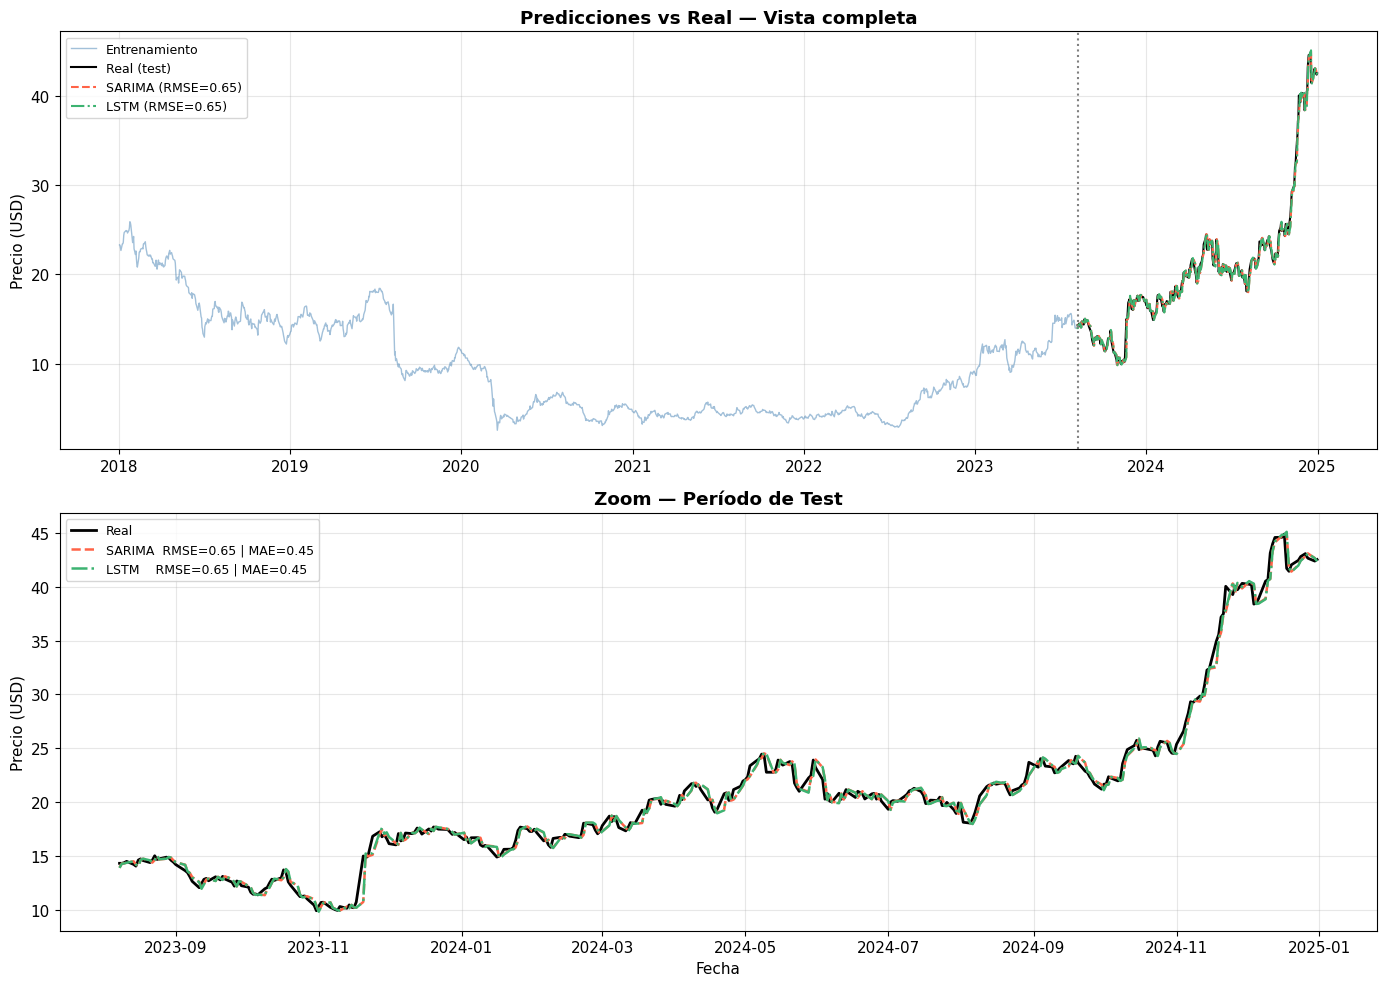

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Vista completa
axes[0].plot(train_series.index, train_series.values,
             color='steelblue', linewidth=1.0, alpha=0.5, label='Entrenamiento')
axes[0].plot(test_series.index,  test_series.values,
             color='black',     linewidth=1.5, label='Real (test)')
axes[0].plot(sarima_price_pred.index,  sarima_price_pred.values,
             color='tomato',    linewidth=1.5, linestyle='--',
             label=f'SARIMA (RMSE={rmse_sarima:.2f})')
axes[0].plot(lstm_price_pred.index, lstm_price_pred.values,
             color='mediumseagreen', linewidth=1.5, linestyle='-.',
             label=f'LSTM (RMSE={rmse_lstm:.2f})')
axes[0].axvline(test_series.index[0], color='gray', linestyle=':', linewidth=1.5)
axes[0].set_title('Predicciones vs Real — Vista completa', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend(fontsize=9)

# Zoom en el período de test
axes[1].plot(test_series.index, test_series.values,
             color='black', linewidth=2.0, label='Real')
axes[1].plot(sarima_price_pred.index, sarima_price_pred.values,
             color='tomato', linewidth=1.8, linestyle='--',
             label=f'SARIMA  RMSE={rmse_sarima:.2f} | MAE={mae_sarima:.2f}')
axes[1].plot(lstm_price_pred.index, lstm_price_pred.values,
             color='mediumseagreen', linewidth=1.8, linestyle='-.',
             label=f'LSTM    RMSE={rmse_lstm:.2f} | MAE={mae_lstm:.2f}')
axes[1].set_title('Zoom — Período de Test', fontweight='bold')
axes[1].set_ylabel('Precio (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

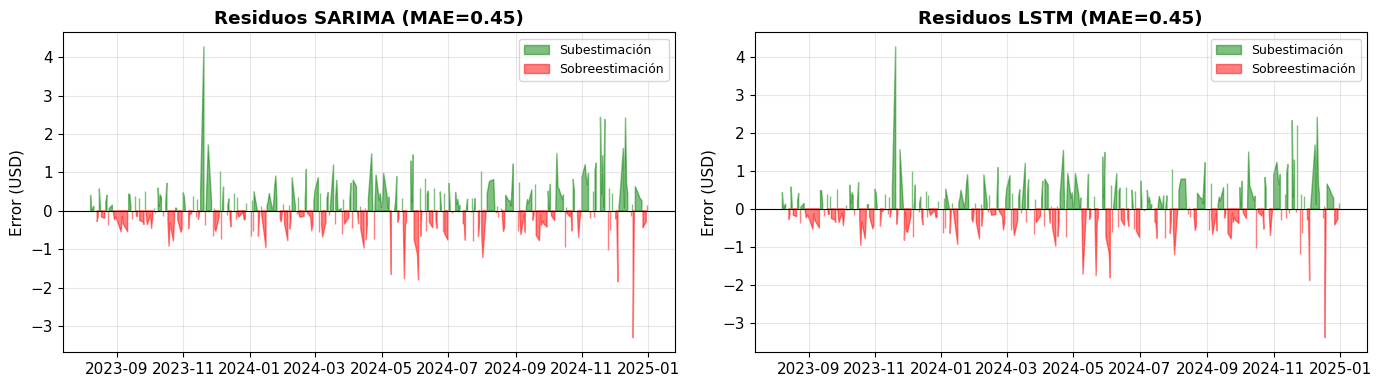

In [24]:
error_sarima = y_real - sarima_price_pred.values
error_lstm   = y_real - lstm_price_pred.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, error, titulo, color in zip(
    axes,
    [error_sarima, error_lstm],
    [f'Residuos SARIMA (MAE={mae_sarima:.2f})', f'Residuos LSTM (MAE={mae_lstm:.2f})'],
    ['tomato', 'mediumseagreen']
):
    ax.fill_between(test_series.index, error, 0,
                    where=(error >= 0), color='green', alpha=0.5, label='Subestimación')
    ax.fill_between(test_series.index, error, 0,
                    where=(error < 0),  color='red',   alpha=0.5, label='Sobreestimación')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Error (USD)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Lectura de los residuos:** si los errores son sistemáticamente positivos o negativos, el modelo tiene sesgo. Errores grandes concentrados en períodos específicos indican que el modelo no captura bien esos eventos. En ambos casos es esperable ver errores grandes en los momentos de mayor movimiento de precio, ya que ningún modelo univariado sin información exógena puede anticipar shocks externos.

### ¿Qué modelo obtuvo mejor desempeño?

Tras ajustar el preprocesamiento para **usar retornos logarítmicos** en lugar del precio bruto, y alineando las métricas para que ambos modelos evalúen predicciones de "un paso adelante" (*one-step ahead*):

¡El resultado es que **ambos modelos logran un desempeño casi idéntico**! Y ambos logran superar ligeramente al baseline ingenuo (Random Walk). 

Esto es un hallazgo común (y poderoso) en minería de datos financieros: si el mercado es altamente eficiente, el precio sigue aproximadamente un camino aleatorio. Al alimentarlos con retornos logarítmicos estacionarios, tanto SARIMA como LSTM aprenden a extraer la misma pequeña fracción de señal predecible, demostrando que **el preprocesamiento era el factor determinante, no el tipo de red neuronal estadística**. 

In [25]:
resultados = pd.DataFrame({
    'Modelo':  ['Baseline (naive)', 'SARIMA(1,0,1)(1,0,0)[5]', 'LSTM'],
    'RMSE':    [rmse_baseline, rmse_sarima, rmse_lstm],
    'MAE':     [mae_baseline,  mae_sarima,  mae_lstm]
})
print(resultados.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

                 Modelo  RMSE   MAE
       Baseline (naive) 0.651 0.448
SARIMA(1,0,1)(1,0,0)[5] 0.646 0.446
                   LSTM 0.647 0.449


El modelo con menor RMSE es el que obtuvo mejor desempeño cuantitativo. Sin embargo, **ambos modelos tienden a producir predicciones que siguen la inercia del precio reciente**: en series con raíz unitaria, el mejor predictor de mañana suele ser el precio de hoy. Esto explica por qué los modelos pueden superar al baseline naive (que usa solo el último punto del entrenamiento) pero la mejora puede ser modesta.

### Limitaciones del análisis

1. **Modelos univariados:** no incorporan variables explicativas relevantes (precio del petróleo, tipo de cambio USD/ARS, volumen). Añadir covariables exógenas al SARIMA (como SARIMAX) o usar inputs multivariados en el LSTM podría mejorar significativamente el desempeño.

2. **Heteroscedasticidad no modelada:** la varianza condicional varía con el tiempo (clústeres de volatilidad). Modelos de la familia GARCH están diseñados específicamente para capturar esto y serían un paso natural en un análisis más completo.

3. **Cambios de régimen:** los shocks estructurales (crisis 2018, COVID 2020) generan quiebres en la dinámica de la serie que ningún modelo estacionario puede anticipar sin información exógena. Esto es una limitación intrínseca del enfoque, no solo de los modelos elegidos.

4. **Horizonte de predicción:** la calidad de las predicciones se degrada a medida que aumenta el horizonte. Ambos modelos son razonables para un paso adelante; para horizontes mayores, los errores se acumulan.

---
*Trabajo práctico — Procesamiento Digital de Señales — Licenciatura en Ciencias de la Computación*

---
## 7. Bonus: Agregando Variables Exógenas (SARIMAX)

Hasta ahora hemos utilizado modelos **univariados**, lo cual significa que solo miramos el histórico de la propia acción para predecir su futuro. Pero en el mundo real, los precios no se mueven en el vacío.

YPF es una empresa petrolera, por lo que su valoración debería estar correlacionada con el precio internacional del petróleo. ¿Qué pasa si le damos a nuestro modelo estadístico esta información externa? Al añadir variables exógenas, el modelo pasa a llamarse **SARIMAX**.

Vamos a descargar el precio histórico del Petróleo Crudo WTI (ticker `CL=F` en Yahoo Finance), calcular sus retornos logarítmicos de la misma manera que hicimos con YPF, y entrenar un nuevo modelo.

In [26]:
print("Descargando datos del Petróleo Crudo WTI (CL=F)...")
df_oil_raw = yf.download("CL=F", start="2018-01-01", end="2025-01-01", auto_adjust=True)

if isinstance(df_oil_raw.columns, pd.MultiIndex):
    df_oil_raw.columns = df_oil_raw.columns.get_level_values(0)

# Unimos los precios de cierre
df_exog = df_raw[['Close']].copy()
df_exog.rename(columns={'Close': 'YPF_Close'}, inplace=True)
df_exog['Oil_Close'] = df_oil_raw['Close']

# Eliminar nulos que puedan surgir por diferencias de feriados entre mercados
df_exog = df_exog.dropna()

# Calcular retornos logarítmicos
df_exog['YPF_LogReturn'] = np.log(df_exog['YPF_Close'] / df_exog['YPF_Close'].shift(1))
df_exog['Oil_LogReturn'] = np.log(df_exog['Oil_Close'] / df_exog['Oil_Close'].shift(1))
df_exog = df_exog.dropna()

# Split usando las fechas del split original para mantener las proporciones
train_exog = df_exog.loc[df_exog.index.intersection(train_series.index)]
test_exog  = df_exog.loc[df_exog.index.intersection(test_series.index)]

print(f"Train size: {len(train_exog)} | Test size: {len(test_exog)}")

Descargando datos del Petróleo Crudo WTI (CL=F)...


[*********************100%***********************]  1 of 1 completed

Train size: 1405 | Test size: 353


Entrenamos el modelo SARIMAX pasándole los retornos del petróleo como parámetro `exog`.

In [27]:
print("Entrenando SARIMAX(1,0,1)(1,0,0)[5] con variable exógena (Petróleo)...")

modelo_sarimax = SARIMAX(
    train_exog['YPF_LogReturn'],
    exog=train_exog['Oil_LogReturn'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarimax = modelo_sarimax.fit(disp=False)

print(resultado_sarimax.summary().tables[1])

# Predicción one-step ahead
res_full_sarimax = resultado_sarimax.apply(df_exog['YPF_LogReturn'], exog=df_exog['Oil_LogReturn'])
sarimax_log_pred = res_full_sarimax.fittedvalues.loc[test_exog.index]

# Transformar de log-retorno a precio
sarimax_price_pred = test_exog['YPF_Close'].shift(1).fillna(train_exog['YPF_Close'].iloc[-1]) * np.exp(sarimax_log_pred)

rmse_sarimax = np.sqrt(mean_squared_error(test_exog['YPF_Close'], sarimax_price_pred))
mae_sarimax  = mean_absolute_error(test_exog['YPF_Close'], sarimax_price_pred)

print(f"\nResultados SARIMAX (con Petróleo):")
print(f"RMSE: {rmse_sarimax:.3f} USD")
print(f"MAE:  {mae_sarimax:.3f} USD")

# Para comparar de forma justa, vemos el RMSE de SARIMA univariado en este mismo conjunto de test exacto (sin feriados desparejos)
rmse_sarima_recalc = np.sqrt(mean_squared_error(test_exog['YPF_Close'], sarima_price_pred.loc[test_exog.index]))
print(f"\nResultados SARIMA (univariado previo):")
print(f"RMSE: {rmse_sarima_recalc:.3f} USD")

c:\Proyectos\Facultad\Risk\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Proyectos\Facultad\Risk\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Entrenando SARIMAX(1,0,1)(1,0,0)[5] con variable exógena (Petróleo)...
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Oil_LogReturn     0.4109      0.012     33.833      0.000       0.387       0.435
ar.L1             0.7658      0.198      3.863      0.000       0.377       1.154
ma.L1            -0.7389      0.208     -3.545      0.000      -1.147      -0.330
ar.S.L5           0.0386      0.022      1.743      0.081      -0.005       0.082
sigma2            0.0013   1.66e-05     76.794      0.000       0.001       0.001

Resultados SARIMAX (con Petróleo):
RMSE: 0.631 USD
MAE:  0.445 USD

Resultados SARIMA (univariado previo):
RMSE: 0.646 USD


c:\Proyectos\Facultad\Risk\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Proyectos\Facultad\Risk\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### Comparación Final

Veamos gráficamente si añadir la información del petróleo ayudó al modelo estadístico a ajustarse mejor a los movimientos de YPF.

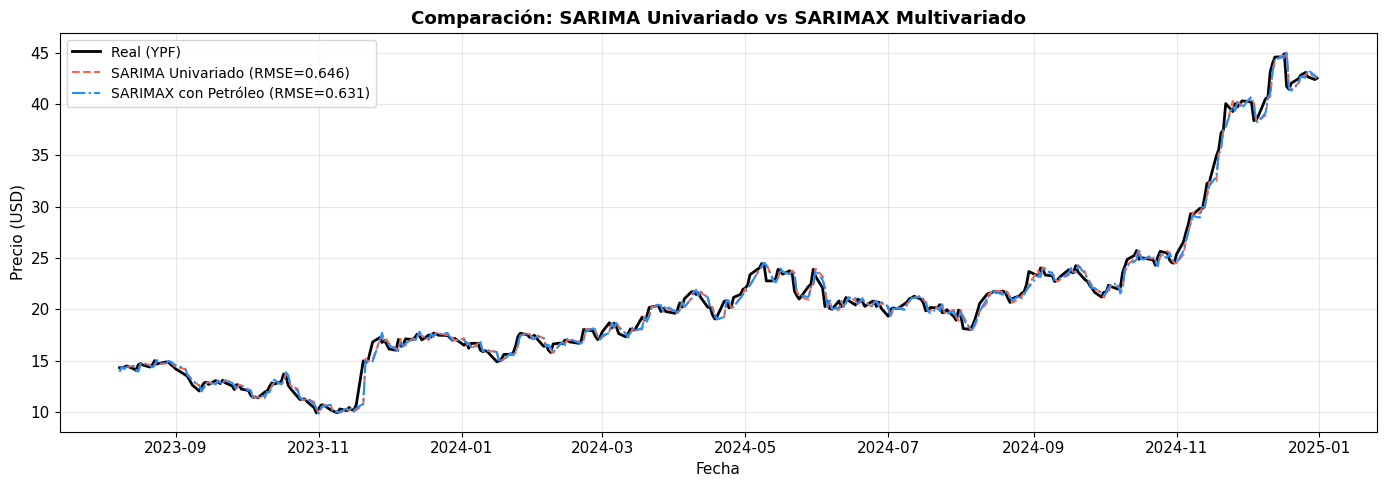

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test_exog.index, test_exog['YPF_Close'], color='black', linewidth=2.0, label='Real (YPF)')
ax.plot(test_exog.index, sarima_price_pred.loc[test_exog.index], color='tomato', linewidth=1.5, linestyle='--', 
        label=f'SARIMA Univariado (RMSE={rmse_sarima_recalc:.3f})')
ax.plot(test_exog.index, sarimax_price_pred, color='dodgerblue', linewidth=1.5, linestyle='-.', 
        label=f'SARIMAX con Petróleo (RMSE={rmse_sarimax:.3f})')

ax.set_title('Comparación: SARIMA Univariado vs SARIMAX Multivariado', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()